# 1. Imports & Setup

In [2]:
import os                           # file operations
import zipfile                      # read dataset archives
from io import BytesIO              # in-memory binary streams
from datetime import datetime      # timestamp filenames
from collections import defaultdict # grouping paths by subject

import numpy as np                  # numerical operations
from PIL import Image               # image I/O
import matplotlib.pyplot as plt     # plotting results
from scipy.ndimage import (
    map_coordinates,                # grid sampling for elastic deformation
    gaussian_filter                 # smoothing displacement fields
)
from tqdm import tqdm               # progress bars

import torch
import torch.nn as nn               # neural network modules
import torch.nn.functional as F     # activation & pooling functions
from torch.amp import (
    autocast,                       # mixed precision context
    GradScaler                     # scale gradients in mixed precision
)
from torch.utils.data import (
    Dataset,                        # custom dataset base class
    DataLoader                      # batching and shuffling data
)
from torchvision.transforms import (
    Compose,                        # chain transforms
    Resize,                         # image resizing
    ToTensor                        # convert PIL to tensor
)

# 2. Elastic Deformation

In [3]:
def elastic_transform(
    image: torch.Tensor,
    alpha: float,
    sigma: float,
    random_state: np.random.RandomState = None
    ) -> torch.Tensor:
    """
    Applies elastic deformation to a single-channel image tensor.

    1. Generate random displacement fields dx, dy
    2. Smooth them with a Gaussian filter (sigma)
    3. Scale by alpha
    4. Create meshgrid of original pixel coords (x, y)
    5. Add displacements: new_x = x + dx, new_y = y + dy
    6. Sample original image at new coords (reflect padding)
    7. Return tensor with same shape
    """
    # Ensure reproducibility
    if random_state is None:
        random_state = np.random.RandomState(None)

    # Convert to NumPy array and remove channel dim
    img_np = image.numpy()[0]
    h, w = img_np.shape

    # Create random displacement fields in [-1,1]
    dx = gaussian_filter((random_state.rand(h, w) * 2 - 1), sigma) * alpha
    dy = gaussian_filter((random_state.rand(h, w) * 2 - 1), sigma) * alpha

    # Original coordinate grid
    x, y = np.meshgrid(np.arange(w), np.arange(h))
    # Distort coordinates
    indices = (
        np.reshape(y + dy, (-1, 1)),
        np.reshape(x + dx, (-1, 1))
    )

    # Map coordinates with reflect mode
    distorted = map_coordinates(img_np, indices, order=1, mode='reflect')
    distorted = torch.tensor(distorted, dtype=image.dtype)
    return distorted.view(1, h, w)

# 3. Dataset Loader (Subject‐wise Split)

In [4]:
class NerveDatasetZip(Dataset):
    """
    Loads ultrasound-nerve-segmentation from a ZIP archive.
    Splits data *frame-wise* (not subject-wise), so each frame
    is shuffled and assigned to train/val/test by fraction.
    Supports optional elastic augmentation on training data.
    """
    def __init__(
        self,
        zip_path: str,
        mode: str = 'train',
        val_split: float = 0.15,
        test_split: float = 0.15,
        resize: tuple = (128, 128),
        seed: int = 1,
        filter_name: str = '',
        elastic: bool = False
    ):
        # — Validate inputs
        assert os.path.isfile(zip_path) and zip_path.endswith('.zip'), \
            f"ZIP file {zip_path} not found or invalid"
        assert mode in ('train','val','test'), "mode must be 'train','val','test'"
        assert 0 <= val_split + test_split <= 1, "val+test splits must sum to <=1"
        
        self.mode    = mode
        self.elastic = elastic
        
        # 1) Open the ZIP
        self.zf = zipfile.ZipFile(zip_path, 'r')
        
        # 2) Build list of all image paths (no "_mask") in train/
        suffix = f"_{filter_name}" if filter_name else ''
        prefix = f"ultrasound-nerve-segmentation{suffix}/train/"
        
        all_images = [
            p for p in self.zf.namelist()
            if p.startswith(prefix)
               and p.endswith('.tif')
               and '_mask' not in p
        ]
        all_images.sort()  # make ordering deterministic before shuffling
        
        # 3) Shuffle globally
        np.random.seed(seed)
        indices = np.random.permutation(len(all_images))
        
        # 4) Compute split sizes
        N       = len(all_images)
        n_test  = int(np.floor(test_split * N))
        n_val   = int(np.floor(val_split  * N))
        n_train = N - n_test - n_val
        
        # 5) Assign index ranges for each mode
        if mode == 'test':
            sel_idx = indices[:n_test]
        elif mode == 'val':
            sel_idx = indices[n_test:n_test + n_val]
        else:  # train
            sel_idx = indices[n_test + n_val:]
        
        # 6) Gather the selected image paths
        self.img_paths  = [all_images[i] for i in sel_idx]
        self.mask_paths = [
            p.replace('.tif', '_mask.tif') for p in self.img_paths
        ]
        
        # 7) Prepare transform
        self.transform = Compose([Resize(resize), ToTensor()])
        
        # 8) Keep filenames for test if needed
        if mode == 'test':
            self.filenames = [os.path.basename(p) for p in self.img_paths]
        else:
            self.filenames = None

    def __len__(self):
        # total frames in this split
        return len(self.img_paths)

    def __getitem__(self, idx: int):
        # Load image and mask from ZIP into PIL → Tensor
        img = Image.open(BytesIO(self.zf.read(self.img_paths[idx]))).convert('L')
        msk = Image.open(BytesIO(self.zf.read(self.mask_paths[idx]))).convert('L')
        
        img_t = self.transform(img)  # 1×H×W
        msk_t = self.transform(msk)
        
        # Elastic augment only on training
        if self.mode == 'train' and self.elastic:
            rng    = np.random.RandomState(np.random.randint(1e6))
            img_t  = elastic_transform(img_t, alpha=34, sigma=4, random_state=rng)
            msk_t  = elastic_transform(msk_t, alpha=34, sigma=4, random_state=rng)
        
        # Return (img, msk, filename) for test, else (img, msk)
        if self.mode == 'test':
            return img_t, msk_t, self.filenames[idx]
        return img_t, msk_t

In [5]:
class NerveDatasetZip(Dataset):
    """
    Loads ultrasound-nerve-segmentation from a ZIP archive.
    Splits data by subject to prevent frame leakage.
    Supports optional elastic augmentation on training data.
    """
    def __init__(
        self,
        zip_path: str,
        mode: str = 'train',
        val_split: float = 0.15,
        test_split: float = 0.15,
        resize: tuple = (128, 128),
        seed: int = 1,
        filter_name: str = '',
        elastic: bool = False
        ):
        # Validate inputs
        assert os.path.isfile(zip_path) and zip_path.endswith('.zip'), \
            f"ZIP file {zip_path} not found or invalid"
        assert mode in ('train','val','test'), "mode must be 'train','val','test'"
        assert 0 <= val_split + test_split <= 1, "val+test splits must sum to <=1"

        self.mode = mode
        self.elastic = elastic
        self.zf = zipfile.ZipFile(zip_path, 'r')

        # Build list of all image paths in 'train/' folder
        suffix = f"_{filter_name}" if filter_name else ''
        prefix = f"ultrasound-nerve-segmentation{suffix}/train/"
        all_paths = [p for p in self.zf.namelist()
                     if p.startswith(prefix)
                     and p.endswith('.tif')
                     and '_mask' not in p]
        all_paths.sort()

        # Group frames by subject ID (filename before underscore)
        subj_map = defaultdict(list)
        for path in all_paths:
            subject = os.path.basename(path).split('_')[0]
            subj_map[subject].append(path)

        # Shuffle subject order
        subj_ids = list(subj_map.keys())
        np.random.seed(seed)
        np.random.shuffle(subj_ids)

        # Determine split indices
        total_subj = len(subj_ids)
        n_test = int(test_split * total_subj)
        n_val  = int(val_split  * total_subj)

        # Assign subjects to splits
        if mode == 'test':
            sel_ids = subj_ids[:n_test]
        elif mode == 'val':
            sel_ids = subj_ids[n_test:n_test + n_val]
        else:  # train
            sel_ids = subj_ids[n_test + n_val:]

        # Collect image and mask paths for chosen subjects
        self.img_paths = [img for sid in sel_ids for img in subj_map[sid]]
        self.mask_paths = [p.replace('.tif','_mask.tif') for p in self.img_paths]

        # Define resize + ToTensor transform
        self.transform = Compose([Resize(resize), ToTensor()])
        self.filenames = [os.path.basename(p) for p in self.img_paths] if mode=='test' else None

    def __len__(self):
        # Return total number of frames in this split
        return len(self.img_paths)

    def __getitem__(self, idx: int):
        # Load image and mask from ZIP
        img = Image.open(BytesIO(self.zf.read(self.img_paths[idx]))).convert('L')
        msk = Image.open(BytesIO(self.zf.read(self.mask_paths[idx]))).convert('L')

        # Apply resize + conversion
        img_t = self.transform(img)  # shape: 1 x H x W
        msk_t = self.transform(msk)

        # Elastic augment only on training
        if self.mode=='train' and self.elastic:
            rng = np.random.RandomState(np.random.randint(1e6))
            img_t = elastic_transform(img_t, alpha=34, sigma=4, random_state=rng)
            msk_t = elastic_transform(msk_t, alpha=34, sigma=4, random_state=rng)

        # Return (image, mask) or (image, mask, filename) for test
        if self.mode=='test':
            return img_t, msk_t, self.filenames[idx]
        return img_t, msk_t


# 4. U-Net Model Definition

In [6]:
class UNet(nn.Module):
    """
    4-level U-Net with dropout for binary segmentation.

    Architecture:
      Encoder (downsampling):
        - conv_block(in_channels → out_channels, applies two Conv→BN→ReLU→Dropout)
        - 2×2 max-pooling to halve spatial dims
      Bottleneck:
        - conv_block with increased dropout
      Decoder (upsampling):
        - 2×2 ConvTranspose to double spatial dims
        - Concatenate skip connection from encoder
        - conv_block on concatenated features
      Final:
        - 1×1 convolution to map to 1 output channel (logits)
    """

    def __init__(self, dropout_prob: float = 0.1):
        super().__init__()
        dp = dropout_prob

        # --- Encoder: four levels of conv + pooling ---
        self.enc1 = self.conv_block(1,   64, dp)   # input 1→64 channels
        self.enc2 = self.conv_block(64, 128, dp)   # 64→128 channels
        self.enc3 = self.conv_block(128,256, dp)   # 128→256 channels
        self.enc4 = self.conv_block(256,512, dp)   # 256→512 channels

        # --- Bottleneck: deep feature extraction (maybe with higher dropout) ---
        self.bottleneck = self.conv_block(512, 1024, dp)

        # --- Decoder: mirror of encoder with upsampling and skip connections ---
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = self.conv_block(512 + 512, 512, dp)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = self.conv_block(256 + 256, 256, dp)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self.conv_block(128 + 128, 128, dp)

        self.up1 = nn.ConvTranspose2d(128,  64, kernel_size=2, stride=2)
        self.dec1 = self.conv_block(64 + 64,   64, dp)

        # --- Final 1×1 convolution to produce logits ---
        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def conv_block(self, in_channels: int, out_channels: int, dp: float) -> nn.Sequential:
        """
        Helper: two successive 3×3 convolutions each followed by:
          - BatchNorm
          - ReLU activation
          - 2D Dropout (dp)
        """
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dp),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dp),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # --- Encoder forward pass ---
        e1 = self.enc1(x)                     # → [64, H, W]
        e2 = self.enc2(F.max_pool2d(e1, 2))   # → [128, H/2, W/2]
        e3 = self.enc3(F.max_pool2d(e2, 2))   # → [256, H/4, W/4]
        e4 = self.enc4(F.max_pool2d(e3, 2))   # → [512, H/8, W/8]

        # --- Bottleneck ---
        b  = self.bottleneck(F.max_pool2d(e4, 2))  # → [1024, H/16, W/16]

        # --- Decoder with skip connections ---
        d4 = self.up4(b)                         # → [512, H/8, W/8]
        d4 = self.dec4(torch.cat([e4, d4], dim=1))

        d3 = self.up3(d4)                        # → [256, H/4, W/4]
        d3 = self.dec3(torch.cat([e3, d3], dim=1))

        d2 = self.up2(d3)                        # → [128, H/2, W/2]
        d2 = self.dec2(torch.cat([e2, d2], dim=1))

        d1 = self.up1(d2)                        # → [64, H, W]
        d1 = self.dec1(torch.cat([e1, d1], dim=1))

        # --- Final logits output ---
        return self.final(d1)                   # → [1, H, W]


# 5. Metrics & Losses

In [7]:
def dice_coef(pred: torch.Tensor, target: torch.Tensor, eps: float=1e-6) -> float:
    """Compute binary Dice score after thresholding at 0.5"""
    pred_bin = (torch.sigmoid(pred)>0.5).float()
    inter = (pred_bin * target).sum()
    return (2*inter+eps)/(pred_bin.sum()+target.sum()+eps)

def iou(pred: torch.Tensor, target: torch.Tensor, eps: float=1e-6) -> float:
    """Compute binary IoU after thresholding at 0.5"""
    pred_bin = (torch.sigmoid(pred)>0.5).float()
    inter = (pred_bin * target).sum()
    union= pred_bin.sum()+target.sum()-inter
    return (inter+eps)/(union+eps)

class DiceLoss(nn.Module):
    """Soft Dice loss: 1 - (2*intersection)/(sum)"""
    def forward(self, pred: torch.Tensor, target: torch.Tensor, eps: float=1e-6) -> torch.Tensor:
        p = torch.sigmoid(pred)
        inter = (p * target).sum()
        union = p.sum() + target.sum()
        return 1 - (2*inter+eps)/(union+eps)

def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.Linear)):
        nn.init.xavier_normal_(m.weight)     # Xavier normal for weights
        if m.bias is not None:
            nn.init.zeros_(m.bias)           # zero biases

# 6. Training Loop

In [8]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    device: torch.device,
    epochs: int,
    lr: float,
    patience: int,
    loss_fns: tuple = (nn.BCEWithLogitsLoss(), DiceLoss()),
    loss_weights: tuple = (0.5,0.5),
    model_filename: str='best_model.pth'
    ) -> dict:
    """
    Trains the model using:
      - Adam optimizer
      - OneCycleLR scheduler
      - Mixed precision (autocast + GradScaler)
      - Early stopping based on validation loss
    Returns history of losses and dice scores.
    """
    optimizer = torch.optim.Adam(model.parameters(), lr)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr,
        steps_per_epoch=len(train_loader),
        epochs=epochs,
        pct_start=0.3,
        anneal_strategy='cos',
        div_factor=25.0,
        final_div_factor=1e4
    )
    scaler = GradScaler('cuda')
    best_val = float('inf')
    wait = 0
    history = {'train_losses':[], 'val_losses':[], 'val_dices':[]}

    for ep in range(1, epochs+1):
        # ---- Training Phase ----
        model.train()
        train_loss = 0.0
        for imgs,masks in tqdm(train_loader, desc=f"Epoch {ep}/{epochs} - Training"):
            imgs, masks = imgs.to(device), masks.to(device)
            with autocast('cuda'):
                logits = model(imgs)
                loss = sum(w*fn(logits,masks) for fn,w in zip(loss_fns,loss_weights))
            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            train_loss += loss.item()
        avg_train = train_loss/len(train_loader)

        # ---- Validation Phase ----
        model.eval()
        val_loss = 0.0
        dice_list=[]
        with torch.no_grad():
            for imgs,masks in val_loader:
                imgs,masks=imgs.to(device),masks.to(device)
                with autocast('cuda'):
                    logits = model(imgs)
                    loss = sum(w*fn(logits,masks) for fn,w in zip(loss_fns,loss_weights))
                val_loss += loss.item()
                # accumulate sample-wise dice
                for logit,gt in zip(logits,masks):
                    dice_list.append(dice_coef(logit.cpu(),gt.cpu()))
        avg_val = val_loss/len(val_loader)
        avg_dice = np.mean(dice_list)

        # Record history and print
        history['train_losses'].append(avg_train)
        history['val_losses'].append(avg_val)
        history['val_dices'].append(avg_dice)
        print(f"Epoch {ep:02d} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | Dice: {avg_dice:.4f}")

        # Early stopping & save best
        if avg_val < best_val:
            best_val=avg_val; wait=0
        else:
            wait+=1
            if wait>=patience:
                print("Early stopping triggered.")
                break
        scheduler.step()

    # Save the best model
    torch.save(model.state_dict(),model_filename)
    print(f"Best model saved to {model_filename}")
    # Return training history
    return history

# 7. Main Script (Training, Plotting & Evaluation)

In [9]:
# Set random seed for reproducibility
seed = 123

# Check if CUDA is available and set device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA available:", torch.cuda.is_available(), flush=True)

if torch.cuda.is_available():
    print("GPU device:", torch.cuda.get_device_name(0))

# Hyperparameters
val_split       = 0.20                          # fraction of subjects for validation
test_split      = 0.10                          # fraction of subjects for testing
filters         = ["raw", "2Dfilter", "clahe"]  # dataset variants
batch_size      = 64                            # samples per batch
epochs          = 50                            # training epochs
lr              = 5e-4                          # learning rate
patience        = epochs                        # early stopping patience
resize_dims     = (128, 128)                    # input image size
dp_rate         = 0.00                          # dropout rate for model

# Loss configuration
loss_fns        = (nn.BCEWithLogitsLoss(), DiceLoss())  # primary loss functions
loss_weights    = (0.0, 1.0)                 # relative weights for each loss

# Data augmentation
elastic_augment = False                      # enable elastic deformation on train set

# Timestamp for file names
timestamp       = datetime.now().strftime("%Y%m%d_%H%M%S")
results = {}

# ----------------------
# Training Loop
# ----------------------
for variant in filters:
    print(f" === Training variant: {variant or 'raw'} ===")

    # Select ZIP path based on filter
    if variant == "raw":
        # No filter applied, use original dataset
        print(f"Loading dataset with {filter} images.")
        zip_path = r"C:\Users\manik\OneDrive - Johns Hopkins\DL Project\ultrasound-nerve-segmentation_raw_OnlyNerve.zip"
    elif variant == "2Dfilter":
        # 2D filter applied, use filtered dataset
        print(f"Loading dataset with {filter} filtered images.")
        zip_path = r"C:\Users\manik\OneDrive - Johns Hopkins\DL Project\ultrasound-nerve-segmentation_2Dfilter_OnlyNerve.zip"
    elif variant == "clahe":
        # CLAHE filter applied, use filtered dataset
        print(f"Loading dataset with {filter} filtered images.")
        zip_path = r"C:\Users\manik\OneDrive - Johns Hopkins\DL Project\ultrasound-nerve-segmentation_clahe_OnlyNerve.zip"

    # Initialize datasets and dataloaders
    train_ds = NerveDatasetZip(
        zip_path,
        mode='train',
        val_split=val_split,
        test_split=test_split,
        resize=resize_dims,
        seed=seed,
        filter_name=variant,
        elastic=elastic_augment
    )
    val_ds = NerveDatasetZip(
        zip_path,
        mode='val',
        val_split=val_split,
        test_split=test_split,
        resize=resize_dims,
        seed=seed,
        filter_name=variant,
        elastic=False
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    # Initialize model and train
    model = UNet(dropout_prob=dp_rate).to(device)
    model.apply(init_weights)  # Initialize weights

    model_filename = (
        f"Unet_{variant or 'raw'}_{timestamp}.pth"
    )
    history = train_model(
        model,
        train_loader,
        val_loader,
        device,
        epochs=epochs,
        lr=lr,
        patience=patience,
        loss_fns=loss_fns,
        loss_weights=loss_weights,
        model_filename=model_filename
    )
    results[variant or 'raw'] = history

CUDA available: True
GPU device: NVIDIA GeForce RTX 4060
 === Training variant: raw ===
Loading dataset with <class 'filter'> images.


Epoch 1/50 - Training: 100%|██████████| 26/26 [00:11<00:00,  2.22it/s]


Epoch 01 | Train: 0.9292 | Val: 0.9421 | Dice: 0.0242


Epoch 2/50 - Training: 100%|██████████| 26/26 [00:11<00:00,  2.33it/s]


Epoch 02 | Train: 0.8842 | Val: 0.9166 | Dice: 0.1237


...

Epoch 48 | Train: 0.3618 | Val: 0.4816 | Dice: 0.7605


Epoch 49/50 - Training: 100%|██████████| 26/26 [00:11<00:00,  2.23it/s]


Epoch 49 | Train: 0.3558 | Val: 0.4684 | Dice: 0.7683


Epoch 50/50 - Training: 100%|██████████| 26/26 [00:11<00:00,  2.23it/s]


Epoch 50 | Train: 0.3493 | Val: 0.4478 | Dice: 0.7703
Best model saved to Unet_clahe_20250427_024417.pth


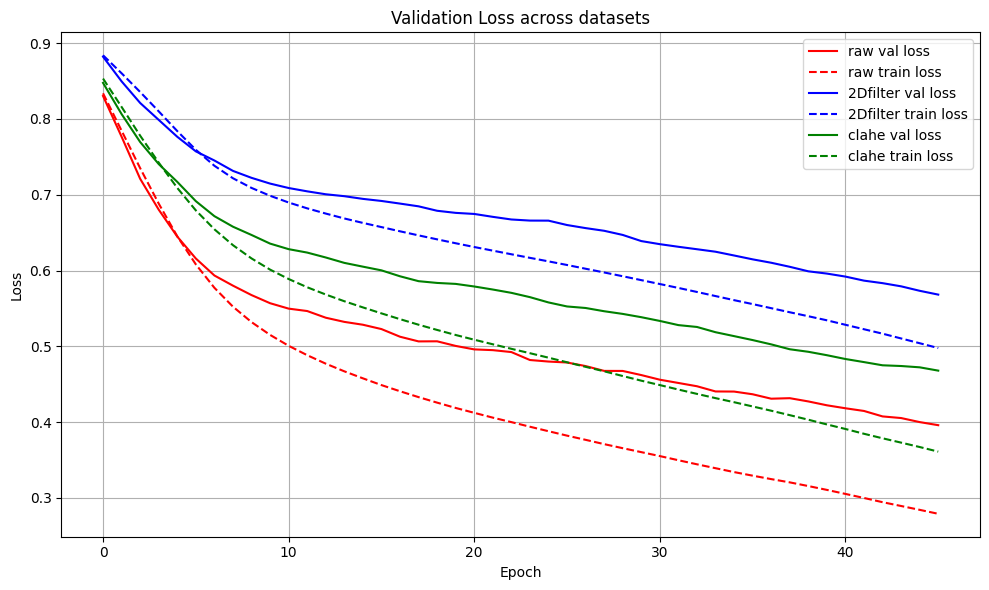

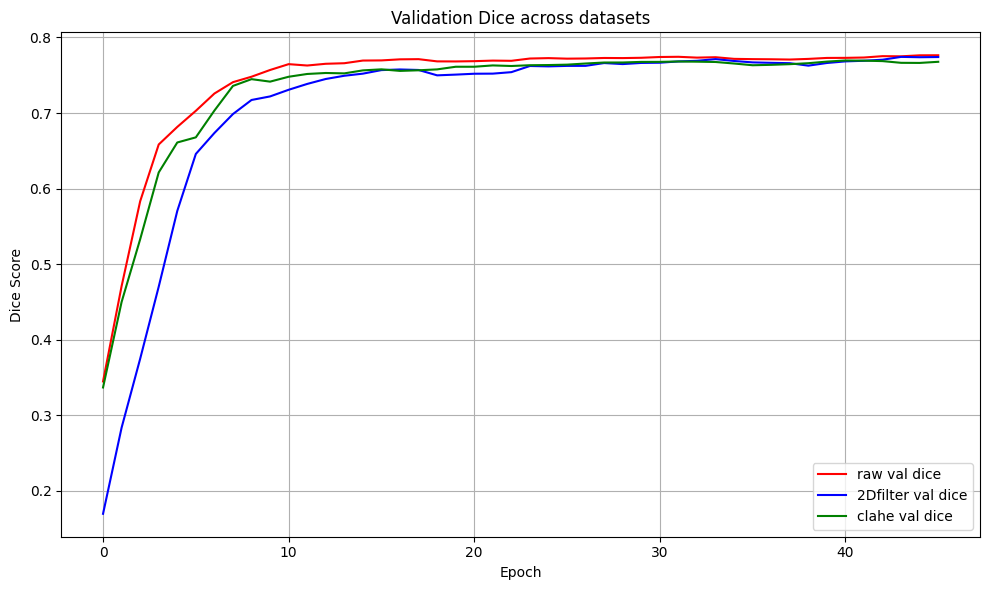

In [16]:
# ----------------------
# Plot Validation Results
# ----------------------
# Validation Loss
plt.figure(figsize=(10,6))
for key, hist in results.items():
    # Plot validation loss (solid) and training loss (dashed)
    # use r b g for raw, 2Dfilter, clahe
    # apply smoothing to the loss curves

    if key == 'raw':
        plt.plot(np.convolve(hist['val_losses'], np.ones(5)/5, mode='valid')  , label=f"{key} val loss", color='r')
        plt.plot(np.convolve(hist['train_losses'], np.ones(5)/5, mode='valid'), label=f"{key} train loss", linestyle='--', color='r')
    elif key == '2Dfilter':
        plt.plot(np.convolve(hist['val_losses'], np.ones(5)/5, mode='valid')  , label=f"{key} val loss", color='b')
        plt.plot(np.convolve(hist['train_losses'], np.ones(5)/5, mode='valid'), label=f"{key} train loss", linestyle='--', color='b')
    elif key == 'clahe':
        plt.plot(np.convolve(hist['val_losses'], np.ones(5)/5, mode='valid')  , label=f"{key} val loss", color='g')
        plt.plot(np.convolve(hist['train_losses'], np.ones(5)/5, mode='valid'), label=f"{key} train loss", linestyle='--', color='g')
plt.title('Validation Loss across datasets')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"val_losses_{timestamp}.png", dpi=300)
plt.show()

# Validation Dice
plt.figure(figsize=(10,6))
for key, hist in results.items():
    # Plot validation dice score (solid)
    # use r b g for raw, 2Dfilter, clahe
    if key == 'raw':
        plt.plot(np.convolve(hist['val_dices'], np.ones(5)/5, mode='valid'), label=f"{key} val dice", color='r')
    elif key == '2Dfilter':
        plt.plot(np.convolve(hist['val_dices'], np.ones(5)/5, mode='valid'), label=f"{key} val dice", color='b')
    elif key == 'clahe':
        plt.plot(np.convolve(hist['val_dices'], np.ones(5)/5, mode='valid'), label=f"{key} val dice", color='g')

plt.title('Validation Dice across datasets')
plt.xlabel('Epoch')
plt.ylabel('Dice Score')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.savefig(f"val_dice_{timestamp}.png", dpi=300)
plt.show()

In [11]:
# ----------------------
# Testing & Final Summary
# ----------------------
test_results = {}
for variant in filters:
    print(f" === Testing variant: {variant or 'raw'} ===")
    
    # Select ZIP path based on filter
    if variant == "raw":
        # No filter applied, use original dataset
        print(f"Loading dataset with {filter} images.")
        zip_path = r"C:\Users\manik\OneDrive - Johns Hopkins\DL Project\ultrasound-nerve-segmentation_raw_OnlyNerve.zip"
    elif variant == "2Dfilter":
        # 2D filter applied, use filtered dataset
        print(f"Loading dataset with {filter} filtered images.")
        zip_path = r"C:\Users\manik\OneDrive - Johns Hopkins\DL Project\ultrasound-nerve-segmentation_2Dfilter_OnlyNerve.zip"
    elif variant == "clahe":
        # CLAHE filter applied, use filtered dataset
        print(f"Loading dataset with {filter} filtered images.")
        zip_path = r"C:\Users\manik\OneDrive - Johns Hopkins\DL Project\ultrasound-nerve-segmentation_clahe_OnlyNerve.zip"

    test_ds = NerveDatasetZip(
        zip_path,
        mode='test',
        val_split=val_split,
        test_split=test_split,
        resize=resize_dims,
        seed=seed,
        filter_name=variant,
        elastic=False
    )
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

    # Load best model checkpoint
    checkpoint = f"Unet_{variant or 'raw'}_{timestamp}.pth"
    model = UNet(dropout_prob=dp_rate).to(device)
    model.load_state_dict(torch.load(checkpoint, map_location=device))
    model.eval()

    dice_scores, iou_scores = [], []
    with torch.no_grad():
        for imgs, masks, _ in tqdm(test_loader, desc="Testing Loop"):
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            for logit, gt in zip(logits, masks):
                dice_scores.append(dice_coef(logit.cpu(), gt.cpu()))
                iou_scores.append(iou(logit.cpu(), gt.cpu()))

    test_results[variant or 'raw'] = {
        'dice': np.mean(dice_scores),
        'iou':  np.mean(iou_scores)
    }

# Summary printout
print("Final Test Results:")
for key, val in test_results.items():
    print(f"{key:>6} | Dice: {val['dice']:.4f} | IoU: {val['iou']:.4f}")

 === Testing variant: raw ===
Loading dataset with <class 'filter'> images.


Testing Loop: 100%|██████████| 232/232 [00:01<00:00, 151.34it/s]


 === Testing variant: 2Dfilter ===
Loading dataset with <class 'filter'> filtered images.


Testing Loop: 100%|██████████| 232/232 [00:01<00:00, 145.03it/s]


 === Testing variant: clahe ===
Loading dataset with <class 'filter'> filtered images.


Testing Loop: 100%|██████████| 232/232 [00:01<00:00, 148.38it/s]

Final Test Results:
   raw | Dice: 0.7655 | IoU: 0.6438
2Dfilter | Dice: 0.7628 | IoU: 0.6401
 clahe | Dice: 0.7629 | IoU: 0.6355


# 8. Display Best & Worst Test Examples

Loading dataset with <class 'filter'> images.


Eval raw: 100%|██████████| 232/232 [00:01<00:00, 153.77it/s]


Loading dataset with <class 'filter'> filtered images.


Eval 2Dfilter: 100%|██████████| 232/232 [00:01<00:00, 148.01it/s]


Loading dataset with <class 'filter'> filtered images.


Eval clahe: 100%|██████████| 232/232 [00:01<00:00, 147.47it/s]


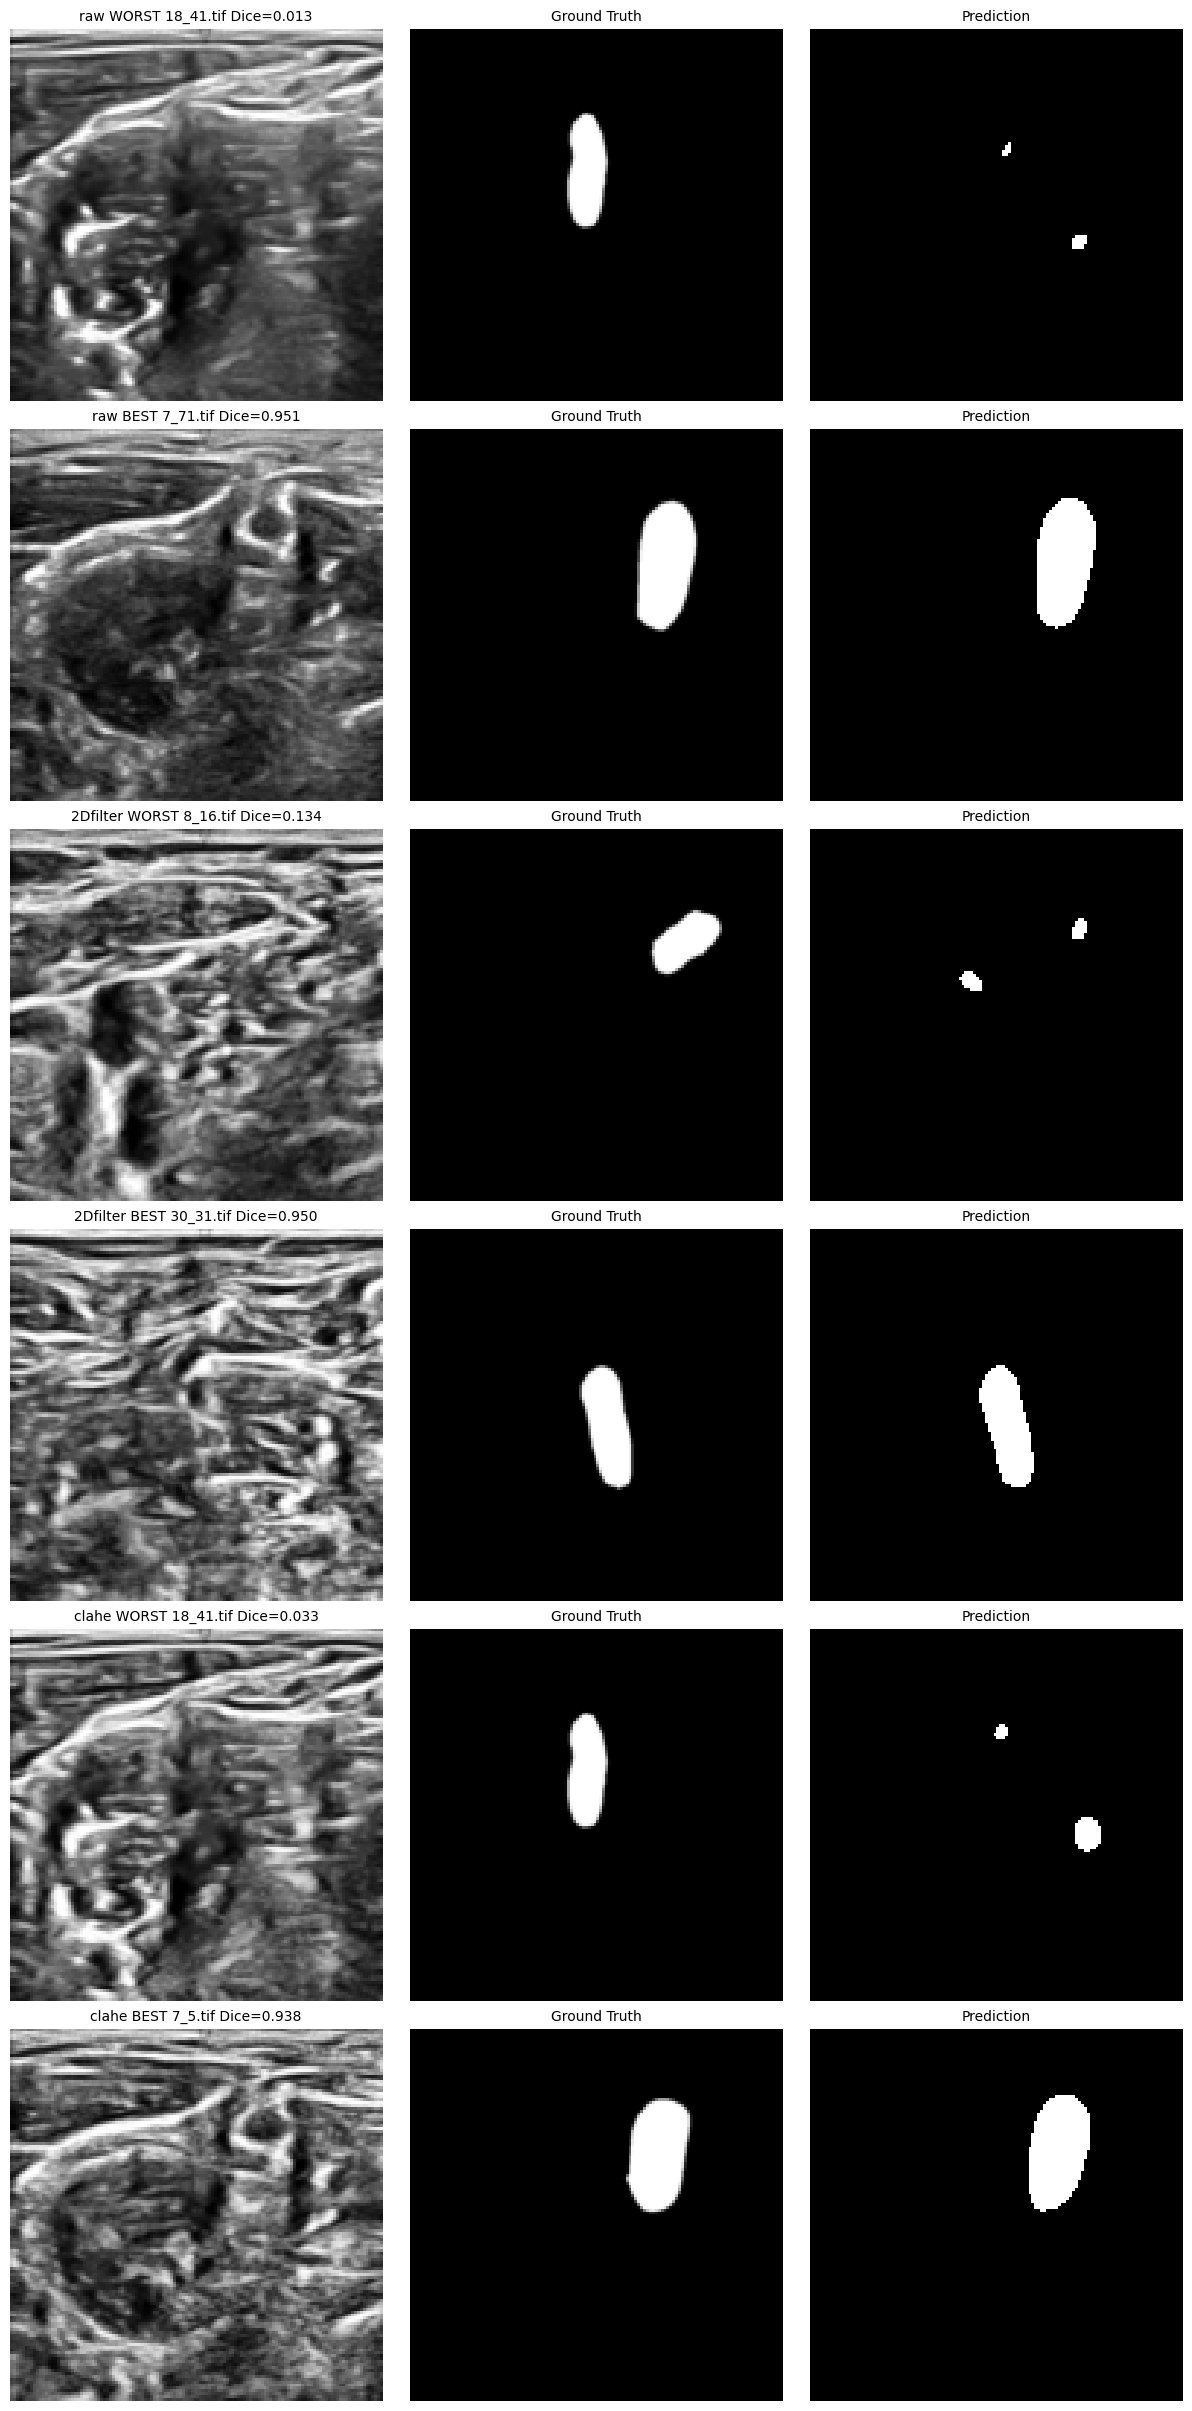

In [12]:
# 1) Prepare a 2×len(filters) grid
n = len(filters)
fig, axes = plt.subplots(n * 2, 3, figsize=(12, 4 * n * 2), constrained_layout=True)

for i, variant in enumerate(filters):
    
    # Select ZIP path based on filter
    if variant == "raw":
        # No filter applied, use original dataset
        print(f"Loading dataset with {filter} images.")
        zip_path = r"C:\Users\manik\OneDrive - Johns Hopkins\DL Project\ultrasound-nerve-segmentation_raw_OnlyNerve.zip"
    elif variant == "2Dfilter":
        # 2D filter applied, use filtered dataset
        print(f"Loading dataset with {filter} filtered images.")
        zip_path = r"C:\Users\manik\OneDrive - Johns Hopkins\DL Project\ultrasound-nerve-segmentation_2Dfilter_OnlyNerve.zip"
    elif variant == "clahe":
        # CLAHE filter applied, use filtered dataset
        print(f"Loading dataset with {filter} filtered images.")
        zip_path = r"C:\Users\manik\OneDrive - Johns Hopkins\DL Project\ultrasound-nerve-segmentation_clahe_OnlyNerve.zip"

    test_ds = NerveDatasetZip(
        zip_path, mode='test',
        val_split=val_split, test_split=test_split,
        resize=resize_dims, seed=seed,
        filter_name=variant, elastic=False
    )
    test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0)

    # --- load model ---
    ckpt = f"Unet_{variant or 'raw'}_{timestamp}.pth"
    model = UNet(dropout_prob=dp_rate).to(device)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()

    # --- collect metrics & examples ---
    examples = []
    dice_scores = []
    iou_scores  = []
    with torch.no_grad():
        for imgs, masks, fnames in tqdm(test_loader, desc=f"Eval {variant or 'raw'}"):
            imgs, masks = imgs.to(device), masks.to(device)
            logits = model(imgs)
            for logit, gt, fname in zip(logits, masks, fnames):
                d = dice_coef(logit.cpu(), gt.cpu()).item()
                iu = iou(logit.cpu(), gt.cpu()).item()
                dice_scores.append(d)
                iou_scores.append(iu)
                # keep only non-zero, non-perfect for best/worst
                if 1e-6 < d < 1:
                    examples.append((d, imgs.cpu()[0], gt.cpu()[0], fname))

    # --- pick worst & best ---
    examples.sort(key=lambda x: x[0])
    worst_d, worst_img, worst_gt, worst_fname = examples[0]
    best_d,  best_img,  best_gt,  best_fname  = examples[-1]

    # --- helper to binarize ---
    def bin_pred(img_t):
        with torch.no_grad():
            logit = model(img_t.unsqueeze(0).to(device))
            return (torch.sigmoid(logit) > 0.5).cpu()[0,0]

    worst_pred = bin_pred(worst_img)
    best_pred  = bin_pred(best_img)

    # row indices in the 2×n grid
    r_w = 2*i
    r_b = 2*i + 1

    # --- plot worst row ---
    for col, (data, title) in enumerate([
        (worst_img.squeeze(0).numpy(), f"{variant or 'raw'} WORST {worst_fname} Dice={worst_d:.3f}"),
        (worst_gt.squeeze(0).numpy(),    "Ground Truth"),
        (worst_pred.numpy(),             "Prediction")
    ]):
        ax = axes[r_w, col]
        ax.imshow(data, cmap='gray', interpolation='nearest')
        ax.set_title(title, fontsize=10)
        ax.axis('off')

    # --- plot best row ---
    for col, (data, title) in enumerate([
        (best_img.squeeze(0).numpy(), f"{variant or 'raw'} BEST {best_fname} Dice={best_d:.3f}"),
        (best_gt.squeeze(0).numpy(),  "Ground Truth"),
        (best_pred.numpy(),           "Prediction")
    ]):
        ax = axes[r_b, col]
        ax.imshow(data, cmap='gray', interpolation='nearest')
        ax.set_title(title, fontsize=10)
        ax.axis('off')

plt.show()
